In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler

from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor

from pathlib import Path
import joblib

In [2]:
BASE_DIR = Path().resolve().parent

df = pd.read_csv(BASE_DIR / "data" / "bike_clean.csv")

In [3]:
X = df.drop(columns="cnt")
y = df["cnt"]

print(f"Número de observaciones: {len(df)}")
print(f"Número de variables predictoras: {X.shape[1]}")
print(f"Variable objetivo: {y.name}")

display(X.head())
display(y.head().to_frame())

Número de observaciones: 17377
Número de variables predictoras: 13
Variable objetivo: cnt


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,is_extreme_temp
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,0
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,0
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,0
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,0
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0


,cnt
0,16
1,40
2,32
3,13
4,1


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [5]:
print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (13901, 13)
Test:  (3476, 13)


In [6]:
categorical_features = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]
numeric_features = [
    "temp",
    "atemp",
    "hum",
    "windspeed"
]

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [8]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [9]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

In [10]:
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.1))
])

In [11]:
tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        DecisionTreeRegressor(
            max_depth=10,
            min_samples_leaf=10,
            random_state=42
        )
    )
])

In [12]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )
    )
])

In [13]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)

    train_r2 = r2_score(y_train, y_train_pred)

    return {
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
        "Overfitting": train_r2 - r2
    }

In [14]:
models = {
    "Linear": linear_pipeline,
    "Ridge": ridge_pipeline,
    "Lasso": lasso_pipeline,
    "Decision Tree": tree_pipeline,
    "XGBoost": xgb_pipeline
}
results = {}

for name, model in models.items():

    results[name] = evaluate_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

In [15]:
results_df = pd.DataFrame(results).T

results_df

,MSE,MAE,R2,Overfitting
Linear,10131.411491,74.421565,0.669988,0.019444
Ridge,10128.221151,74.410377,0.670092,0.019337
Lasso,10124.645803,74.312918,0.670209,0.018875
Decision Tree,8915.716152,69.570279,0.709587,0.039889
XGBoost,2220.468506,31.440624,0.927672,0.026658


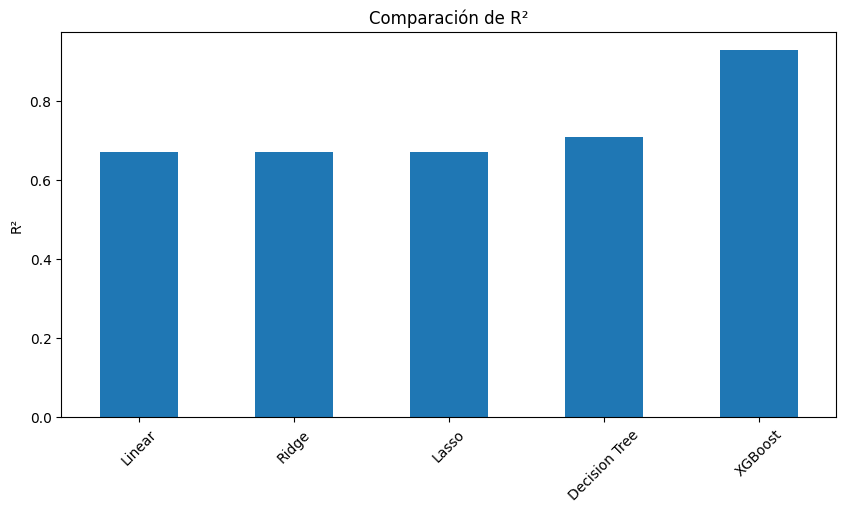

In [16]:
results_df["R2"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparación de R²")
plt.ylabel("R²")
plt.xticks(rotation=45)
plt.show()

In [17]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [18]:
for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="r2"
    )

    print(
        f"{name}: "
        f"{scores.mean():.3f} "
        f"(±{scores.std():.3f})"
    )

Linear: 0.683 (±0.008)
Ridge: 0.683 (±0.008)
Lasso: 0.683 (±0.008)
Decision Tree: 0.710 (±0.010)
XGBoost: 0.929 (±0.003)


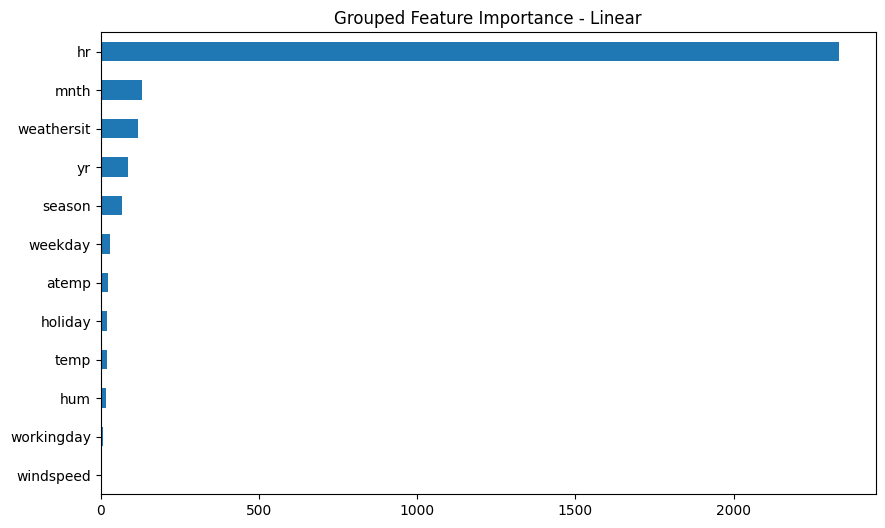

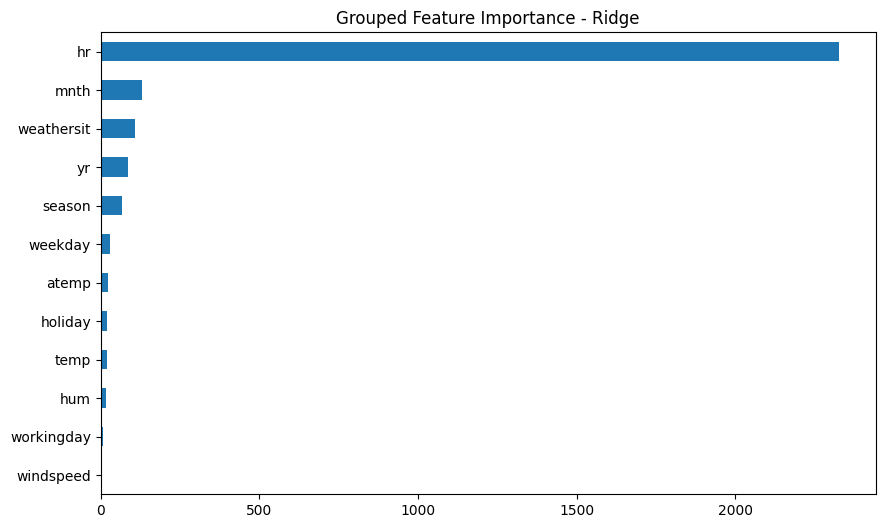

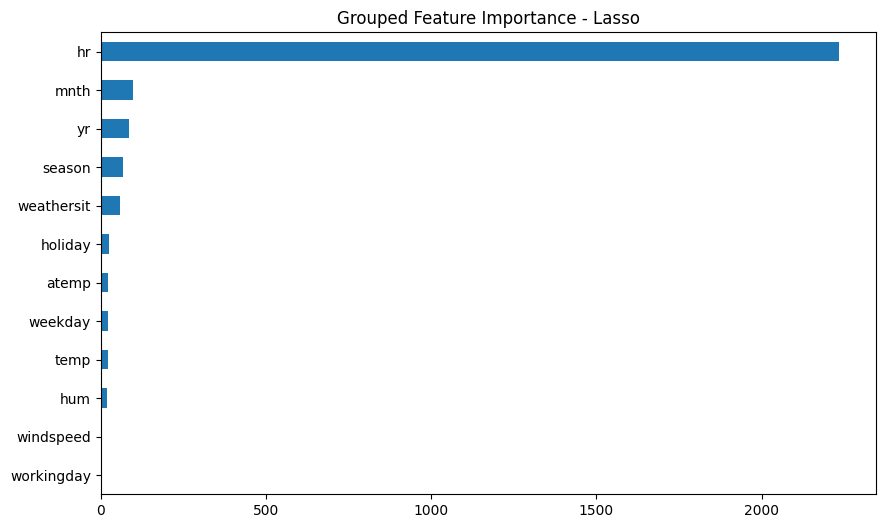

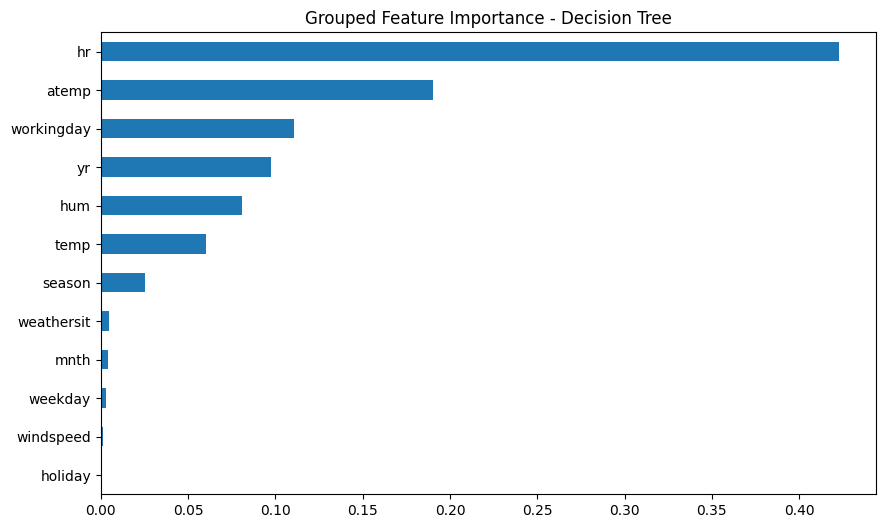

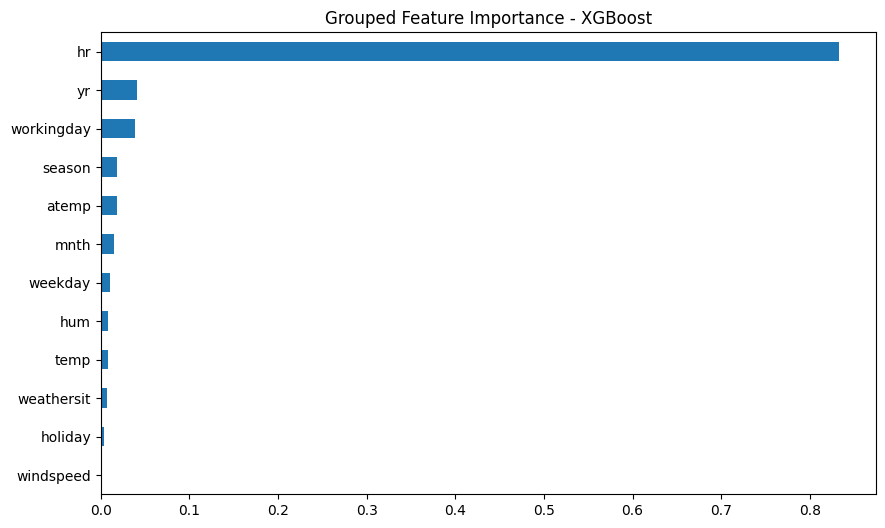

In [19]:
models = {
    "Linear": linear_pipeline,
    "Ridge": ridge_pipeline,
    "Lasso": lasso_pipeline,
    "Decision Tree": tree_pipeline,
    "XGBoost": xgb_pipeline
}

all_importances = {}

for name, model in models.items():

    estimator = model.named_steps["model"]

    # importancia
    if hasattr(estimator, "coef_"):
        importance = np.abs(estimator.coef_)
    else:
        importance = estimator.feature_importances_

    # nombres de features
    ohe = model.named_steps["preprocessor"].named_transformers_["cat"]
    cat_names = ohe.get_feature_names_out(categorical_features)
    feature_names = list(numeric_features) + list(cat_names)

    fi = pd.Series(importance, index=feature_names)

    grouped = {}

    for feature, value in fi.items():
        base = feature.split("_")[0]
        grouped[base] = grouped.get(base, 0) + value

    grouped = pd.Series(grouped).sort_values(ascending=True)

    all_importances[name] = grouped

    # plot
    plt.figure(figsize=(10,6))
    grouped.tail(15).plot(kind="barh")
    plt.title(f"Grouped Feature Importance - {name}")
    plt.show()

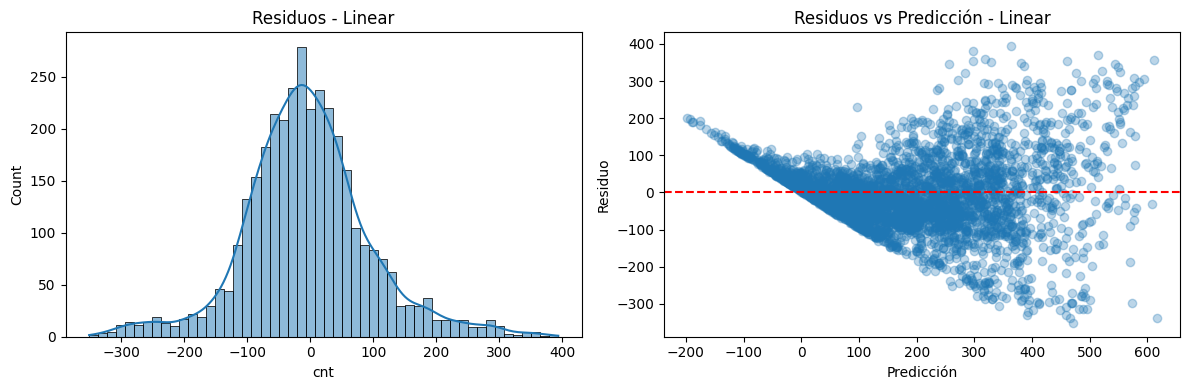

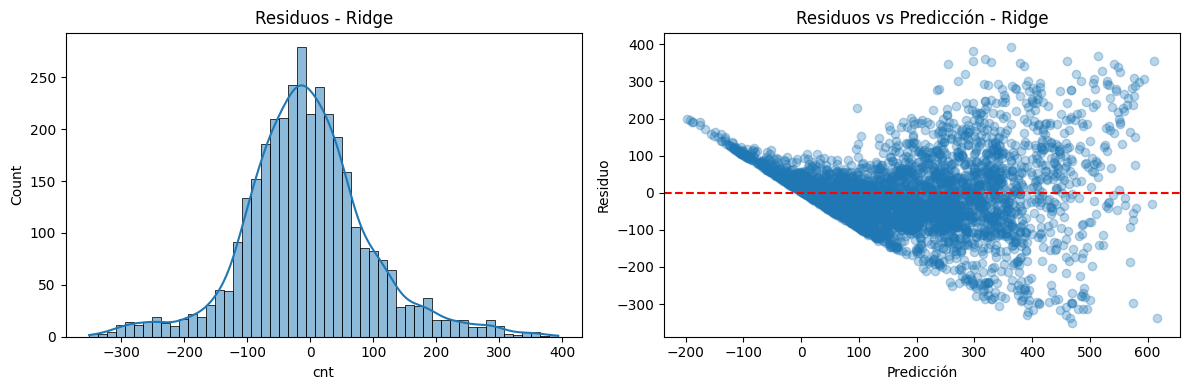

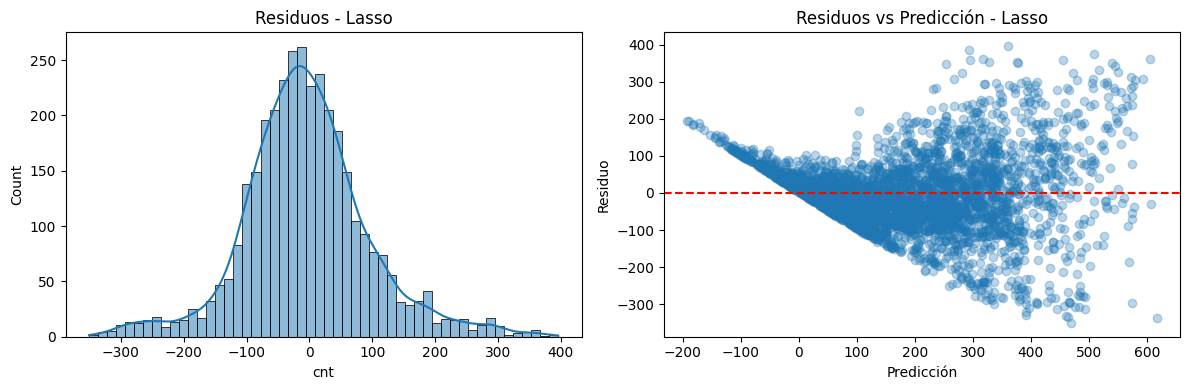

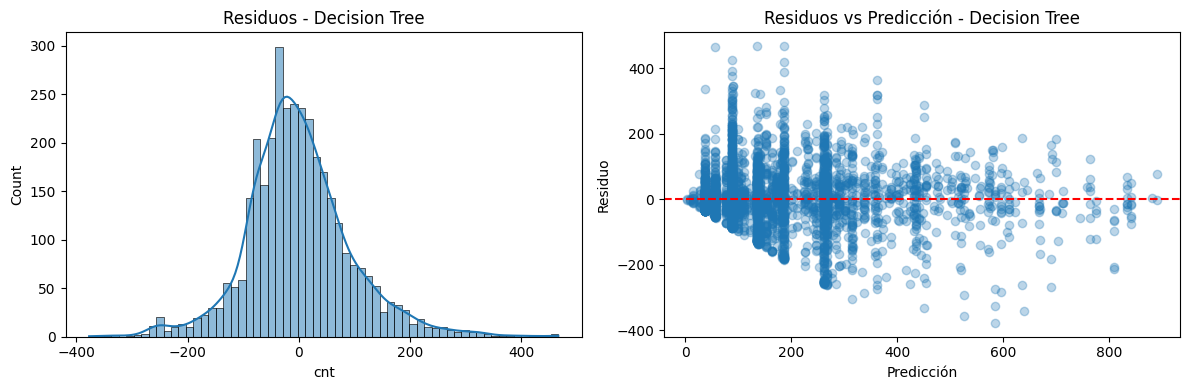

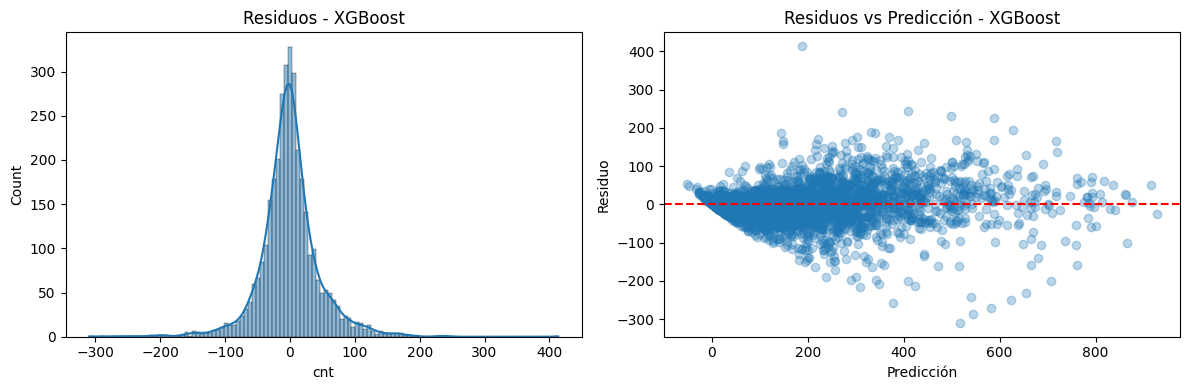

In [20]:
models = {
    "Linear": linear_pipeline,
    "Ridge": ridge_pipeline,
    "Lasso": lasso_pipeline,
    "Decision Tree": tree_pipeline,
    "XGBoost": xgb_pipeline
}

residuals_dict = {}

for name, model in models.items():

    # predicción
    y_pred = model.predict(X_test)

    # residuos
    residuals = y_test - y_pred
    residuals_dict[name] = residuals

    # gráfico
    plt.figure(figsize=(12,4))

    # distribución
    plt.subplot(1,2,1)
    sns.histplot(residuals, kde=True)
    plt.title(f"Residuos - {name}")

    # residuos vs predicción
    plt.subplot(1,2,2)
    plt.scatter(y_pred, residuals, alpha=0.3)
    plt.axhline(0, color="red", linestyle="--")
    plt.title(f"Residuos vs Predicción - {name}")
    plt.xlabel("Predicción")
    plt.ylabel("Residuo")

    plt.tight_layout()
    plt.show()

In [21]:
for name, res in residuals_dict.items():
    print(name, np.mean(np.abs(res)))

Linear 74.4215654543314
Ridge 74.41037679092868
Lasso 74.31291844316587
Decision Tree 69.57027946151483
XGBoost 31.440623557608216


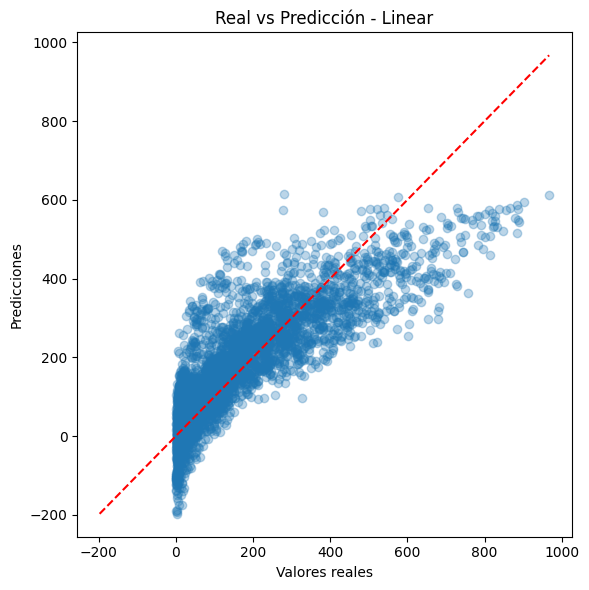

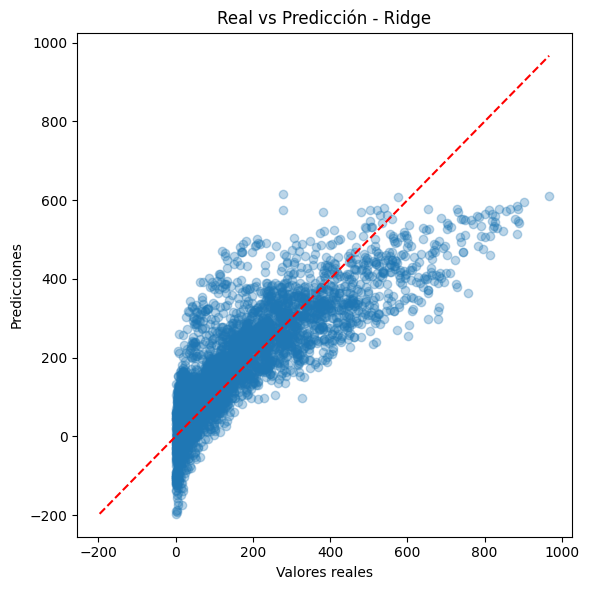

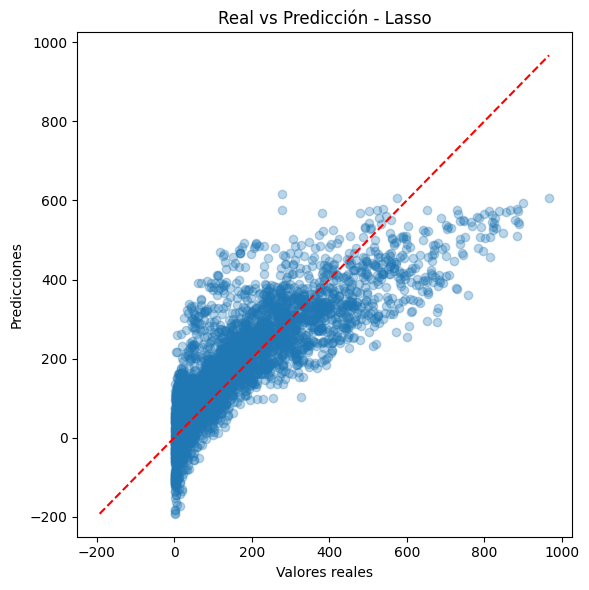

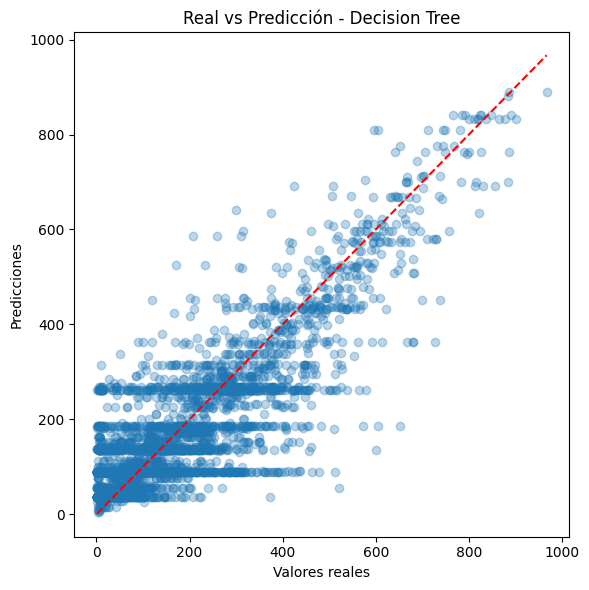

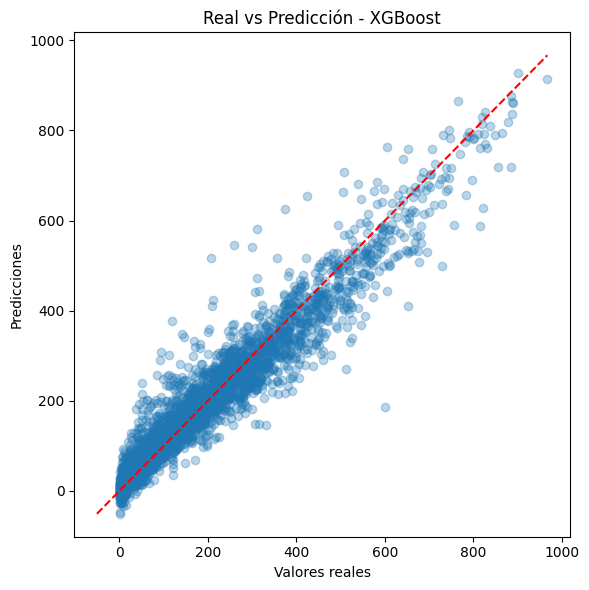

In [22]:
models = {
    "Linear": linear_pipeline,
    "Ridge": ridge_pipeline,
    "Lasso": lasso_pipeline,
    "Decision Tree": tree_pipeline,
    "XGBoost": xgb_pipeline
}

for name, model in models.items():

    # predicción
    y_pred = model.predict(X_test)

    plt.figure(figsize=(6,6))

    plt.scatter(y_test, y_pred, alpha=0.3)

    # línea perfecta (y = x)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")

    plt.title(f"Real vs Predicción - {name}")
    plt.xlabel("Valores reales")
    plt.ylabel("Predicciones")

    plt.tight_layout()
    plt.show()

In [23]:
# carpeta models
models_dir = BASE_DIR / "models"
models_dir.mkdir(exist_ok=True)

models = {
    "linear": linear_pipeline,
    "ridge": ridge_pipeline,
    "lasso": lasso_pipeline,
    "decision_tree": tree_pipeline,
    "xgboost": xgb_pipeline
}

for name, model in models.items():
    path = models_dir / f"{name}_model.pkl"
    joblib.dump(model, path)
    print(f"Modelo guardado: {name} -> {path}")

Modelo guardado: linear -> C:\Users\Don Bosco\Desktop\bootcamp-da-p2\DA-Project-Regression-Grupo1\models\linear_model.pkl
Modelo guardado: ridge -> C:\Users\Don Bosco\Desktop\bootcamp-da-p2\DA-Project-Regression-Grupo1\models\ridge_model.pkl
Modelo guardado: lasso -> C:\Users\Don Bosco\Desktop\bootcamp-da-p2\DA-Project-Regression-Grupo1\models\lasso_model.pkl
Modelo guardado: decision_tree -> C:\Users\Don Bosco\Desktop\bootcamp-da-p2\DA-Project-Regression-Grupo1\models\decision_tree_model.pkl
Modelo guardado: xgboost -> C:\Users\Don Bosco\Desktop\bootcamp-da-p2\DA-Project-Regression-Grupo1\models\xgboost_model.pkl
